In [1]:
# ============================================================
# Cell 1 : Imports
# ============================================================

import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from glob import glob
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import (
    convnext_tiny,
    ConvNeXt_Tiny_Weights
)

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.manifold import TSNE

warnings.filterwarnings("ignore")

print("=" * 70)
print("Libraries Imported Successfully")
print("=" * 70)

Libraries Imported Successfully


In [2]:
# ============================================================
# Cell 2 : Configuration
# ============================================================

DEVICE = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else

    "cpu"

)

IMAGE_SIZE = 224

BATCH_SIZE = 32

NUM_WORKERS = 2

EMBED_DIM = 768

NUM_CLASSES = 14

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DISEASES = [

    "Atelectasis",
    "Cardiomegaly",
    "Effusion",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pneumonia",
    "Pneumothorax",
    "Consolidation",
    "Edema",
    "Emphysema",
    "Fibrosis",
    "Pleural_Thickening",
    "Hernia"

]

print("=" * 70)

print("Device :", DEVICE)

print("Embedding Dimension :", EMBED_DIM)

print("Classes :", NUM_CLASSES)

print("=" * 70)

Device : cuda
Embedding Dimension : 768
Classes : 14


In [3]:
# ============================================================
# Cell 3 : Paths
# ============================================================

# -------------------------
# NIH ChestX-ray14
# -------------------------

NIH_ROOT = "/kaggle/input/datasets/organizations/nih-chest-xrays"

# -------------------------
# ArcFace Model
# -------------------------

ARCFACE_PATH = (

    "/kaggle/input/models/swastikprakash/arconn/"
    "pytorch/default/1/best_arcface_model.pth"

)

# -------------------------
# Prototype Bank
# -------------------------

PROTOTYPE_PATH = (

    "/kaggle/input/models/swastikprakash/path/"
    "pytorch/default/1/prototype_bank.pth"

)

print("="*70)

print("NIH Dataset")

print(NIH_ROOT)

print()

print("ArcFace")

print(ARCFACE_PATH)

print()

print("Prototype Bank")

print(PROTOTYPE_PATH)

print("="*70)

NIH Dataset
/kaggle/input/datasets/organizations/nih-chest-xrays

ArcFace
/kaggle/input/models/swastikprakash/arconn/pytorch/default/1/best_arcface_model.pth

Prototype Bank
/kaggle/input/models/swastikprakash/path/pytorch/default/1/prototype_bank.pth


In [4]:
# ============================================================
# Cell 4 : Verify Files
# ============================================================

print("="*70)

print("NIH Exists :", os.path.exists(NIH_ROOT))

print("ArcFace Exists :", os.path.exists(ARCFACE_PATH))

print("Prototype Exists :", os.path.exists(PROTOTYPE_PATH))

print("="*70)

NIH Exists : True
ArcFace Exists : True
Prototype Exists : True


In [5]:
# ============================================================
# Cell 5 : Inspect ArcFace Checkpoint
# ============================================================

arcface_checkpoint = torch.load(

    ARCFACE_PATH,

    map_location=DEVICE,

    weights_only=False

)

print("="*80)

print("ArcFace Checkpoint Loaded Successfully")

print("="*80)

print(type(arcface_checkpoint))

print()

if isinstance(arcface_checkpoint, dict):

    print("Checkpoint Keys:")

    for key in arcface_checkpoint.keys():

        print(" -", key)

print("="*80)

ArcFace Checkpoint Loaded Successfully
<class 'dict'>

Checkpoint Keys:
 - model_state_dict
 - optimizer_state_dict
 - scheduler_state_dict
 - history
 - best_auc
 - epoch


In [6]:
# ============================================================
# Cell 6 : Load Enhanced Prototype Bank
# ============================================================

prototype_bank = torch.load(

    PROTOTYPE_PATH,

    map_location=DEVICE,

    weights_only=False

)

# --------------------------------------------------------
# Extract Components
# --------------------------------------------------------

prototype_memory = prototype_bank["prototype_memory"]

prototype_weights = prototype_bank["prototype_weights"]

adaptive_thresholds = prototype_bank["adaptive_thresholds"]

EMA_ALPHA = prototype_bank["ema_alpha"]

NUM_PROTOTYPES = prototype_bank["num_prototypes"]

DISEASES = prototype_bank["diseases"]

print("=" * 80)

print("Prototype Bank Loaded Successfully")

print("=" * 80)

print("Diseases :", len(DISEASES))

print("Prototype Memory :", type(prototype_memory))

print("Prototype Weights :", type(prototype_weights))

print("Adaptive Thresholds :", type(adaptive_thresholds))

print("EMA Alpha :", EMA_ALPHA)

print("Num Prototypes :", NUM_PROTOTYPES)

print("=" * 80)

Prototype Bank Loaded Successfully
Diseases : 14
Prototype Memory : <class 'dict'>
Prototype Weights : <class 'dict'>
Adaptive Thresholds : <class 'dict'>
EMA Alpha : 0.9
Num Prototypes : 3


In [7]:
# ============================================================
# Cell 7 : ConvNeXt Encoder
# ============================================================

class ConvNeXtEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        backbone = convnext_tiny(
            weights=None
        )

        self.features = backbone.features

        self.avgpool = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):

        x = self.features(x)

        x = self.avgpool(x)

        x = torch.flatten(x, 1)

        x = F.normalize(
            x,
            dim=1
        )

        return x


encoder = ConvNeXtEncoder().to(DEVICE)

print("=" * 70)
print("ConvNeXt Encoder Created")
print("=" * 70)

ConvNeXt Encoder Created


In [8]:
# ============================================================
# Cell 8 : Load Encoder Weights
# ============================================================

state_dict = arcface_checkpoint["model_state_dict"]

encoder_state = {}

for key, value in state_dict.items():

    if key.startswith("encoder."):

        new_key = key.replace("encoder.", "")

        encoder_state[new_key] = value

missing, unexpected = encoder.load_state_dict(

    encoder_state,

    strict=False

)

encoder.eval()

print("=" * 70)

print("Encoder Loaded Successfully")

print()

print("Missing Keys :", len(missing))

print("Unexpected Keys :", len(unexpected))

print("=" * 70)

Encoder Loaded Successfully

Missing Keys : 0
Unexpected Keys : 0


In [9]:
# ============================================================
# Cell 9 : Encoder Sanity Check
# ============================================================

dummy = torch.randn(

    4,

    3,

    IMAGE_SIZE,

    IMAGE_SIZE

).to(DEVICE)

with torch.no_grad():

    embedding = encoder(dummy)

print("=" * 70)

print("Embedding Shape :", embedding.shape)

print("=" * 70)

Embedding Shape : torch.Size([4, 768])


In [10]:
# ============================================================
# Cell 10 : Image Preprocessing
# ============================================================

transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485,0.456,0.406],

        std=[0.229,0.224,0.225]

    )

])

print("="*70)

print("Image Transform Ready")

print("="*70)

Image Transform Ready


In [11]:
# ============================================================
# Cell 11 : Load Single Image
# ============================================================

def load_image(image_path):

    image = cv2.imread(
        image_path,
        cv2.IMREAD_GRAYSCALE
    )

    image = transform(image)

    return image.unsqueeze(0).to(DEVICE)

print("="*70)

print("Image Loader Ready")

print("="*70)

Image Loader Ready


In [12]:
# ============================================================
# Cell 12 : Embedding Extraction
# ============================================================

@torch.no_grad()

def extract_embedding(image_tensor):

    encoder.eval()

    embedding = encoder(image_tensor)

    embedding = F.normalize(

        embedding,

        dim=1

    )

    return embedding

print("="*70)

print("Embedding Extractor Ready")

print("="*70)

Embedding Extractor Ready


In [13]:
# ============================================================
# Cell 13 : Weighted Multi-Prototype Similarity
# ============================================================

@torch.no_grad()

def prototype_similarity(

    embedding,

    prototype_memory,

    prototype_weights

):

    scores = {}

    for disease in DISEASES:

        prototypes = prototype_memory[disease].to(DEVICE)

        weights = prototype_weights[disease].to(DEVICE)

        prototypes = F.normalize(

            prototypes,

            dim=1

        )

        similarity = torch.mm(

            embedding,

            prototypes.T

        ).squeeze(0)

        weighted_similarity = similarity * weights

        scores[disease] = weighted_similarity.max().item()

    return scores

print("="*70)

print("Weighted Prototype Matcher Ready")

print("="*70)

Weighted Prototype Matcher Ready


In [14]:
# ============================================================
# Cell 14 : Adaptive Prediction
# ============================================================

def predict_diseases(

    similarity_scores,

    adaptive_thresholds

):

    predictions = []

    confidences = []

    for disease in DISEASES:

        score = similarity_scores[disease]

        threshold = adaptive_thresholds[disease]

        if score >= threshold:

            predictions.append(disease)

            confidences.append(score)

    return predictions, confidences

print("="*70)

print("Adaptive Predictor Ready")

print("="*70)

Adaptive Predictor Ready


In [15]:
# ============================================================
# Cell 15 : Complete Inference Pipeline
# ============================================================

def inference(image_path):

    image = load_image(

        image_path

    )

    embedding = extract_embedding(

        image

    )

    similarity = prototype_similarity(

        embedding,

        prototype_memory,

        prototype_weights

    )

    predictions, confidences = predict_diseases(

        similarity,

        adaptive_thresholds

    )

    return {

        "embedding": embedding,

        "similarity": similarity,

        "predictions": predictions,

        "confidence": confidences

    }

print("="*70)

print("Complete Inference Pipeline Ready")

print("="*70)

Complete Inference Pipeline Ready


In [16]:
# ============================================================
# Cell 16 : Generic Chest X-ray Dataset
# ============================================================

class ChestXrayDataset(Dataset):

    def __init__(self, image_paths, labels=None):

        self.image_paths = image_paths
        self.labels = labels

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, idx):

        image = cv2.imread(
            self.image_paths[idx],
            cv2.IMREAD_GRAYSCALE
        )

        image = transform(image)

        if self.labels is None:

            return image, self.image_paths[idx]

        return image, self.labels[idx], self.image_paths[idx]


print("="*70)
print("Generic Dataset Ready")
print("="*70)

Generic Dataset Ready


In [17]:
# ============================================================
# Cell 17 : Evaluate Dataset
# ============================================================

@torch.no_grad()

def evaluate_dataset(loader):

    encoder.eval()

    results = []

    for batch in tqdm(loader):

        if len(batch) == 3:

            images, labels, paths = batch

        else:

            images, paths = batch
            labels = None

        images = images.to(DEVICE)

        embeddings = extract_embedding(images)

        for i in range(images.size(0)):

            similarity = prototype_similarity(

                embeddings[i].unsqueeze(0),

                prototype_memory,

                prototype_weights

            )

            predictions, confidence = predict_diseases(

                similarity,

                adaptive_thresholds

            )

            result = {

                "path": paths[i],

                "predictions": predictions,

                "confidence": confidence,

                "similarity": similarity

            }

            if labels is not None:

                result["label"] = labels[i]

            results.append(result)

    return results


print("="*70)
print("Evaluation Function Ready")
print("="*70)

Evaluation Function Ready


In [18]:
# ============================================================
# Cell 18 : Load NIH Metadata
# ============================================================

NIH_CSV = os.path.join(
    NIH_ROOT,
    "data",
    "Data_Entry_2017.csv"
)

nih_df = pd.read_csv(NIH_CSV)

print("=" * 70)

print("NIH Metadata Loaded")

print("Images :", len(nih_df))

print()

display(nih_df.head())

print("=" * 70)

NIH Metadata Loaded
Images : 112120



,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [19]:
# ============================================================
# Cell 19 : Build NIH Image Index
# ============================================================

image_dict = {}

image_files = glob(

    os.path.join(
        NIH_ROOT,
        "data",
        "images_*",
        "images",
        "*.png"
    )

)

for path in image_files:

    image_dict[os.path.basename(path)] = path

print("=" * 70)

print("Images Indexed :", len(image_dict))

print("=" * 70)

Images Indexed : 112120


In [20]:
# ============================================================
# Cell 20 : Attach Image Paths
# ============================================================

nih_df["image_path"] = nih_df["Image Index"].map(image_dict)

nih_df = nih_df.dropna(subset=["image_path"])

nih_df = nih_df.reset_index(drop=True)

print("=" * 70)

print("Valid Images :", len(nih_df))

print()

print(nih_df[["Image Index","Finding Labels","image_path"]].head())

print("=" * 70)

Valid Images : 112120

        Image Index          Finding Labels  \
0  00000001_000.png            Cardiomegaly   
1  00000001_001.png  Cardiomegaly|Emphysema   
2  00000001_002.png   Cardiomegaly|Effusion   
3  00000002_000.png              No Finding   
4  00000003_000.png                  Hernia   

                                          image_path  
0  /kaggle/input/datasets/organizations/nih-chest...  
1  /kaggle/input/datasets/organizations/nih-chest...  
2  /kaggle/input/datasets/organizations/nih-chest...  
3  /kaggle/input/datasets/organizations/nih-chest...  
4  /kaggle/input/datasets/organizations/nih-chest...  


In [21]:
# ============================================================
# Cell 21 : Encode NIH Labels
# ============================================================

def encode_labels(label_string):

    target = np.zeros(NUM_CLASSES, dtype=np.float32)

    if label_string == "No Finding":

        return target

    labels = label_string.split("|")

    for disease in labels:

        if disease in DISEASES:

            idx = DISEASES.index(disease)

            target[idx] = 1.0

    return target


nih_df["target"] = nih_df["Finding Labels"].apply(encode_labels)

print("=" * 70)

print("NIH Labels Encoded Successfully")

print()

print("Example Label :")

print(nih_df.loc[0, "Finding Labels"])

print(nih_df.loc[0, "target"])

print("=" * 70)

NIH Labels Encoded Successfully

Example Label :
Cardiomegaly
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [22]:
# ============================================================
# Cell 22 : NIH Evaluation Dataset
# ============================================================

class NIHDataset(Dataset):

    def __init__(self, dataframe):

        self.df = dataframe

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = cv2.imread(

            row.image_path,

            cv2.IMREAD_GRAYSCALE

        )

        image = transform(image)

        label = torch.tensor(

            row.target,

            dtype=torch.float32

        )

        return image, label, row.image_path


nih_dataset = NIHDataset(nih_df)

print("=" * 70)

print("NIH Dataset Ready")

print("Samples :", len(nih_dataset))

print("=" * 70)

NIH Dataset Ready
Samples : 112120


In [23]:
# ============================================================
# Cell 23 : NIH DataLoader
# ============================================================

nih_loader = DataLoader(

    nih_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True

)

print("=" * 70)

print("NIH DataLoader Ready")

print("Batches :", len(nih_loader))

print("=" * 70)

NIH DataLoader Ready
Batches : 3504


In [24]:
print(type(prototype_memory))
print(type(prototype_weights))
print(type(adaptive_thresholds))

<class 'dict'>
<class 'dict'>
<class 'dict'>


In [25]:
# ============================================================
# Cell 24 : Run NIH Evaluation
# ============================================================

nih_results = evaluate_dataset(

    nih_loader

)

print("=" * 70)

print("NIH Evaluation Completed")

print()

print("Images Evaluated :", len(nih_results))

print("=" * 70)

  0%|          | 0/3504 [00:00<?, ?it/s]

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNGlibpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


NIH Evaluation Completed

Images Evaluated : 112120


In [26]:
# ============================================================
# Cell 25 : Results DataFrame
# ============================================================

results_df = pd.DataFrame(nih_results)

print("=" * 70)

print("Results DataFrame Created")

print()

print(results_df.head())

print()

print("Total Images :", len(results_df))

print("=" * 70)

Results DataFrame Created

                                                path     predictions  \
0  /kaggle/input/datasets/organizations/nih-chest...  [Cardiomegaly]   
1  /kaggle/input/datasets/organizations/nih-chest...  [Cardiomegaly]   
2  /kaggle/input/datasets/organizations/nih-chest...  [Cardiomegaly]   
3  /kaggle/input/datasets/organizations/nih-chest...  [Mass, Nodule]   
4  /kaggle/input/datasets/organizations/nih-chest...        [Hernia]   

                                 confidence  \
0                      [0.2546195685863495]   
1                     [0.24462267756462097]   
2                     [0.25004392862319946]   
3  [0.251581072807312, 0.29732275009155273]   
4                      [0.4029357135295868]   

                                          similarity  \
0  {'Atelectasis': 0.17121687531471252, 'Cardiome...   
1  {'Atelectasis': 0.14784686267375946, 'Cardiome...   
2  {'Atelectasis': 0.20587158203125, 'Cardiomegal...   
3  {'Atelectasis': 0.196806341409

In [27]:
# ============================================================
# Cell 26 : Known Disease Statistics
# ============================================================

known_count = 0

unknown_count = 0

num_predictions = []

for pred in results_df["predictions"]:

    if len(pred) == 0:

        unknown_count += 1

    else:

        known_count += 1

        num_predictions.append(len(pred))

print("=" * 70)

print("Known Images :", known_count)

print("Unknown Images :", unknown_count)

if len(num_predictions) > 0:

    print()

    print(

        "Average Predicted Diseases :", 

        np.mean(num_predictions)

    )

print("=" * 70)

Known Images : 42371
Unknown Images : 69749

Average Predicted Diseases : 2.4914446201411344


In [28]:
# ============================================================
# Cell 27 : Prediction Confidence
# ============================================================

confidence_scores = []

for conf in results_df["confidence"]:

    confidence_scores.extend(conf)

confidence_scores = np.array(confidence_scores)

print("=" * 70)

print("Total Predictions :", len(confidence_scores))

print()

print("Mean Confidence :", confidence_scores.mean())

print("Std :", confidence_scores.std())

print("Min :", confidence_scores.min())

print("Max :", confidence_scores.max())

print("=" * 70)

Total Predictions : 105565

Mean Confidence : 0.26694350934393374
Std : 0.02975429340135212
Min : 0.2139705866575241
Max : 0.4519610106945038


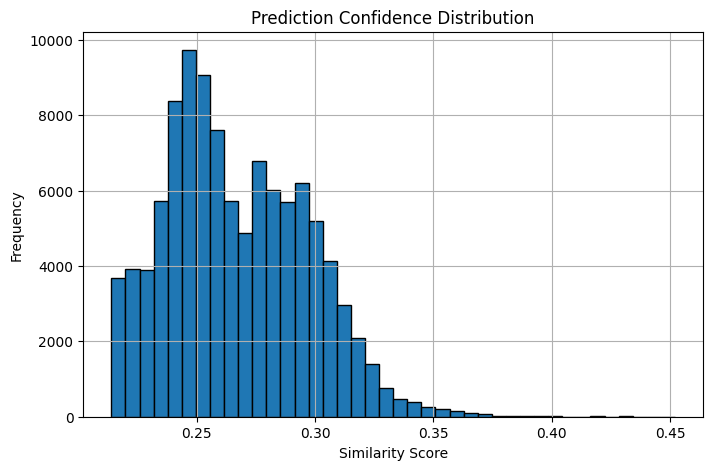

In [29]:
# ============================================================
# Cell 28 : Confidence Histogram
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(

    confidence_scores,

    bins=40,

    edgecolor="black"

)

plt.xlabel("Similarity Score")

plt.ylabel("Frequency")

plt.title("Prediction Confidence Distribution")

plt.grid(True)

plt.show()

,Disease,Count
4,Infiltration,37918
5,Atelectasis,17406
6,Effusion,14974
7,Consolidation,6349
0,Cardiomegaly,5082
8,Pneumonia,4232
1,Mass,4117
11,Pleural_Thickening,3735
12,Edema,3335
10,Pneumothorax,2703


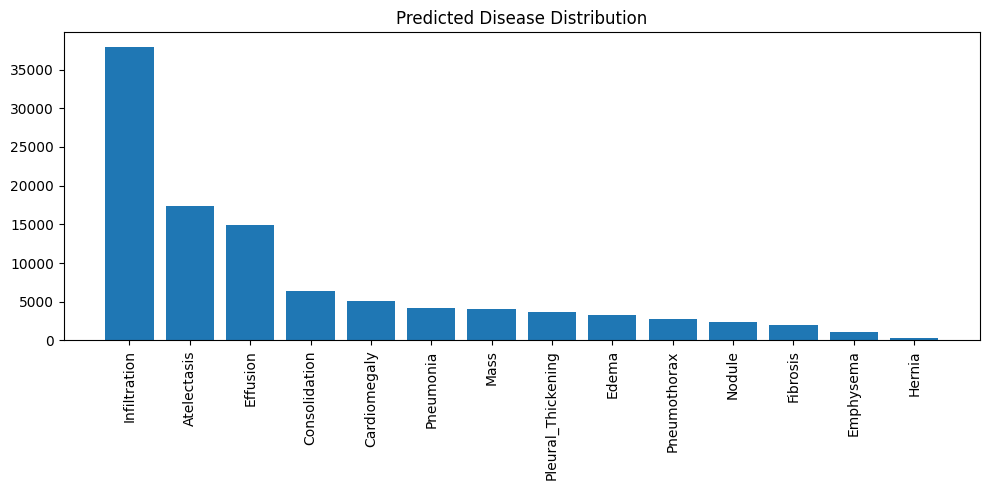

In [30]:
# ============================================================
# Cell 29 : Disease Frequency
# ============================================================

from collections import Counter

counter = Counter()

for pred in results_df["predictions"]:

    counter.update(pred)

freq = pd.DataFrame(

    counter.items(),

    columns=[

        "Disease",

        "Count"

    ]

)

freq = freq.sort_values(

    "Count",

    ascending=False

)

display(freq)

plt.figure(figsize=(10,5))

plt.bar(

    freq["Disease"],

    freq["Count"]

)

plt.xticks(

    rotation=90

)

plt.title(

    "Predicted Disease Distribution"

)

plt.tight_layout()

plt.show()

In [31]:
import os

print("="*80)
print("DATASETS")
print("="*80)

for root, dirs, files in os.walk("/kaggle/input/datasets"):
    print(root)
    if files:
        print(" Files:", files[:5])

DATASETS
/kaggle/input/datasets
/kaggle/input/datasets/organizations
/kaggle/input/datasets/organizations/nih-chest-xrays
/kaggle/input/datasets/organizations/nih-chest-xrays/data
 Files: ['LOG_CHESTXRAY.pdf', 'README_CHESTXRAY.pdf', 'BBox_List_2017.csv', 'test_list.txt', 'ARXIV_V5_CHESTXRAY.pdf']
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images
 Files: ['00006199_010.png', '00004833_016.png', '00006260_000.png', '00004911_010.png', '00004186_007.png']
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_012
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_012/images
 Files: ['00029715_002.png', '00029594_001.png', '00029863_000.png', '00029118_000.png', '00029548_008.png']
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_009
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_009/images
 Files: ['00020450_007.png', '00019464_005.png',

In [32]:
import os

for folder in os.listdir("/kaggle/input/datasets"):
    print(folder)
    print(os.listdir("/kaggle/input/datasets/" + folder))
    print("-"*80)

organizations
['nih-chest-xrays']
--------------------------------------------------------------------------------
andyczhao
['covidx-cxr2']
--------------------------------------------------------------------------------
swastikprakash
['tbx11k']
--------------------------------------------------------------------------------
xhlulu
['vinbigdata-chest-xray-resized-png-1024x1024']
--------------------------------------------------------------------------------


In [33]:
import os

print("="*80)
print("Top-level datasets")
print("="*80)

for org in os.listdir("/kaggle/input/datasets"):
    print("\nORG:", org)

    org_path = os.path.join("/kaggle/input/datasets", org)

    if os.path.isdir(org_path):
        for ds in os.listdir(org_path):
            print("   ", ds)

Top-level datasets

ORG: organizations
    nih-chest-xrays

ORG: andyczhao
    covidx-cxr2

ORG: swastikprakash
    tbx11k

ORG: xhlulu
    vinbigdata-chest-xray-resized-png-1024x1024


In [34]:
import os

ROOT = "/kaggle/input/datasets/xhlulu"   # change this

for root, dirs, files in os.walk(ROOT):
    print(root)
    if files:
        print(files[:5])

/kaggle/input/datasets/xhlulu
/kaggle/input/datasets/xhlulu/vinbigdata-chest-xray-resized-png-1024x1024
['train_meta.csv']
/kaggle/input/datasets/xhlulu/vinbigdata-chest-xray-resized-png-1024x1024/test
['b3f67ac077531f44dd06275af31edbd9.png', 'e94fde220360e4b769921e16059cc6af.png', 'd2993271d0a49d1d821db1174861629a.png', '99732e844196448b90e50973d6ba5224.png', '3c6f70f56258cad13d74e7f17da1c7c5.png']
/kaggle/input/datasets/xhlulu/vinbigdata-chest-xray-resized-png-1024x1024/train
['e8a33efad92e29059710804688d915bc.png', '67d2aa041a3556a12994b0ba36fbdc68.png', 'ac84f263701e0d8668a47ac3e59e4e48.png', 'f3adcfd01d642fb478c008211b135c12.png', '690a74b4ebf969fbadc5ad0a1187968d.png']


In [35]:
import os

DATASETS = [
    "/kaggle/input/datasets/andyczhao/covidx-cxr2",
    "/kaggle/input/datasets/swastikprakash/tbx11k",
    "/kaggle/input/datasets/xhlulu/vinbigdata-chest-xray-resized-png-1024x1024"
]

for dataset in DATASETS:

    print("\n" + "="*80)
    print(dataset)
    print("="*80)

    for root, dirs, files in os.walk(dataset):

        print(root)

        if len(files) > 0:
            print("Files:", files[:5])

        if root.count(os.sep) > dataset.count(os.sep) + 2:
            break


/kaggle/input/datasets/andyczhao/covidx-cxr2
/kaggle/input/datasets/andyczhao/covidx-cxr2
Files: ['val.txt', 'test.txt', 'train.txt']
/kaggle/input/datasets/andyczhao/covidx-cxr2/val
Files: ['COVID(47).png', 'sub-S09736_ses-E25124_run-1_bp-chest_vp-pa_dx-corrected.png', 'sub-S10114_ses-E19830_run-1_bp-chest_vp-ap_cr-corrected.png', '39ebb0a8-3fad-42c6-83d1-b92272c32f6f.png', 'sub-S09678_ses-E22133_run-1_bp-chest_vp-ap_dx-corrected.png']
/kaggle/input/datasets/andyczhao/covidx-cxr2/test
Files: ['sub-S05073_ses-E12362_run-1_bp-chest_vp-pa_dx-corrected.png', 'sub-S06722_ses-E13548_run-1_bp-chest_vp-pa_cr-corrected.png', 'sub-S05456_ses-E10137_run-1_bp-chest_vp-ap_cr-corrected.png', 'sub-S03263_ses-E06433_run-1_bp-chest_vp-ap_dx-corrected.png', 'sub-S06250_ses-E12088_run-1_bp-chest_vp-ap_dx-corrected.png']
/kaggle/input/datasets/andyczhao/covidx-cxr2/train
Files: ['7a530f4d-13af-4e4e-bf2e-080c7fb27ffb.png', '86f084ef-539c-404b-9a91-c9a5d5ab3771.png', 'sub-S332082_ses-E66597_run-1_bp-chest

In [36]:
# ============================================================
# Cell 30 : Unknown Dataset
# ============================================================

class UnknownDataset(Dataset):

    def __init__(self, image_paths):

        self.image_paths = image_paths

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, idx):

        image = cv2.imread(

            self.image_paths[idx],

            cv2.IMREAD_GRAYSCALE

        )

        image = transform(image)

        return image, self.image_paths[idx]


print("="*70)
print("Unknown Dataset Ready")
print("="*70)

Unknown Dataset Ready


In [37]:
# ============================================================
# Cell 31 : Load Unknown Dataset Paths
# ============================================================

COVID_IMAGES = sorted(

    glob(

        "/kaggle/input/datasets/andyczhao/covidx-cxr2/test/*.png"

    )

)

VINBIG_IMAGES = sorted(

    glob(

        "/kaggle/input/datasets/xhlulu/vinbigdata-chest-xray-resized-png-1024x1024/test/*.png"

    )

)

TB_IMAGES = sorted(

    glob(

        "/kaggle/input/datasets/swastikprakash/tbx11k/TBX11K/imgs/**/*.png",

        recursive=True

    )

)

print("="*70)

print("COVIDx :", len(COVID_IMAGES))

print("TBX11K :", len(TB_IMAGES))

print("VinBig :", len(VINBIG_IMAGES))

print("="*70)

COVIDx : 8482
TBX11K : 12174
VinBig : 3000


In [38]:
# ============================================================
# Cell 32 : Unknown DataLoaders
# ============================================================

covid_loader = DataLoader(

    UnknownDataset(COVID_IMAGES),

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0

)

tb_loader = DataLoader(

    UnknownDataset(TB_IMAGES),

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0

)

vin_loader = DataLoader(

    UnknownDataset(VINBIG_IMAGES),

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0

)

print("="*70)

print("Unknown DataLoaders Ready")

print("="*70)

Unknown DataLoaders Ready


In [39]:
# ============================================================
# Cell 33 : Evaluate Unknown Dataset
# ============================================================

@torch.no_grad()

def evaluate_unknown(loader):

    encoder.eval()

    unknown_results = []

    for images, paths in tqdm(loader):

        images = images.to(DEVICE)

        embeddings = extract_embedding(images)

        for i in range(images.size(0)):

            similarity = prototype_similarity(

                embeddings[i].unsqueeze(0),

                prototype_memory,

                prototype_weights

            )

            predictions, confidence = predict_diseases(

                similarity,

                adaptive_thresholds

            )

            unknown_results.append(

                {

                    "path": paths[i],

                    "predictions": predictions,

                    "confidence": confidence,

                    "num_predictions": len(predictions)

                }

            )

    return pd.DataFrame(unknown_results)

print("="*70)

print("Unknown Evaluator Ready")

print("="*70)

Unknown Evaluator Ready


In [40]:
# ============================================================
# Cell 34 : Evaluate COVIDx
# ============================================================

covid_results = evaluate_unknown(

    covid_loader

)

print("="*70)

print("COVIDx Images :", len(covid_results))

print("="*70)

  0%|          | 0/266 [00:00<?, ?it/s]

COVIDx Images : 8482


In [41]:
# ============================================================
# Cell 35 : Evaluate TBX11K
# ============================================================

tb_results = evaluate_unknown(

    tb_loader

)

print("="*70)

print("TBX11K Images :", len(tb_results))

print("="*70)

  0%|          | 0/381 [00:00<?, ?it/s]

TBX11K Images : 12174


In [42]:
# ============================================================
# Cell 36 : Evaluate VinBigData
# ============================================================

vin_results = evaluate_unknown(

    vin_loader

)

print("="*70)

print("VinBig Images :", len(vin_results))

print("="*70)

  0%|          | 0/94 [00:00<?, ?it/s]

VinBig Images : 3000


In [43]:
# ============================================================
# Cell 37 : Known vs Unknown Analysis
# ============================================================

summary = pd.DataFrame({

    "Dataset":[

        "NIH",

        "COVIDx",

        "TBX11K",

        "VinBig"

    ],

    "Images":[

        len(results_df),

        len(covid_results),

        len(tb_results),

        len(vin_results)

    ],

    "Avg Predictions":[

        results_df["predictions"].apply(len).mean(),

        covid_results["num_predictions"].mean(),

        tb_results["num_predictions"].mean(),

        vin_results["num_predictions"].mean()

    ]

})

display(summary)

,Dataset,Images,Avg Predictions
0,NIH,112120,0.941536
1,COVIDx,8482,0.712214
2,TBX11K,12174,0.567028
3,VinBig,3000,0.335000


In [44]:
# ============================================================
# Cell 38 : Unknown Detection Statistics
# ============================================================

def unknown_statistics(df, name):

    unknown = (df["num_predictions"] == 0).sum()

    known = (df["num_predictions"] > 0).sum()

    print("="*70)

    print(name)

    print()

    print("Total Images :", len(df))

    print("Predicted Unknown :", unknown)

    print("Predicted Known :", known)

    print("Unknown Rate : {:.2f}%".format(
        unknown / len(df) * 100
    ))

    print("="*70)

unknown_statistics(covid_results, "COVIDx")

unknown_statistics(tb_results, "TBX11K")

unknown_statistics(vin_results, "VinBig")

COVIDx

Total Images : 8482
Predicted Unknown : 5560
Predicted Known : 2922
Unknown Rate : 65.55%
TBX11K

Total Images : 12174
Predicted Unknown : 9363
Predicted Known : 2811
Unknown Rate : 76.91%
VinBig

Total Images : 3000
Predicted Unknown : 2542
Predicted Known : 458
Unknown Rate : 84.73%


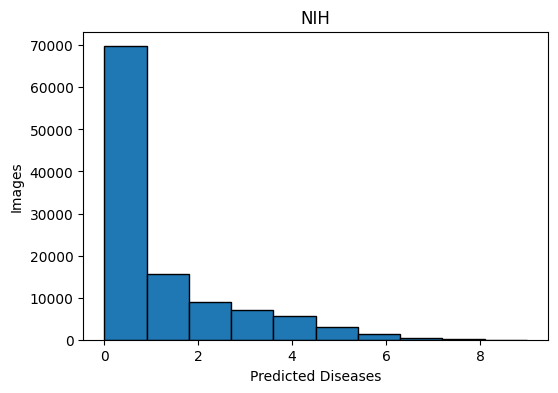

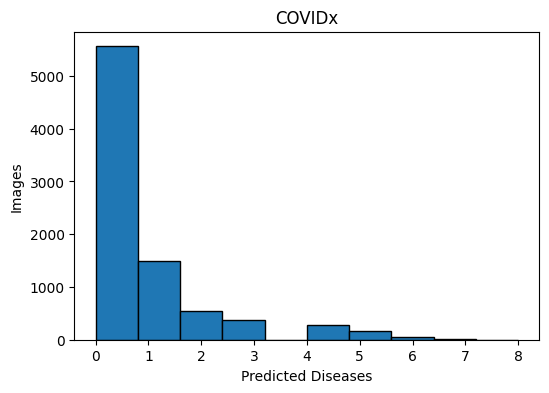

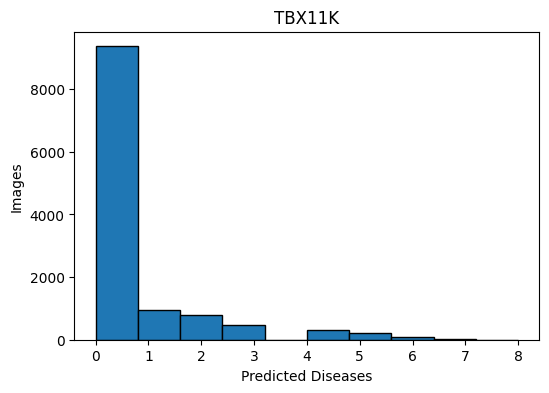

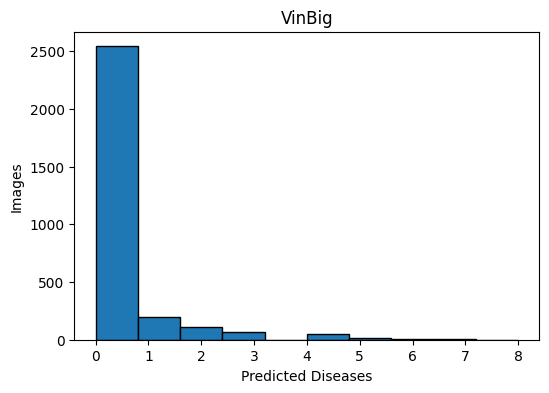

In [45]:
# ============================================================
# Cell 39 : Prediction Distribution
# ============================================================

datasets = {

    "NIH":results_df,

    "COVIDx":covid_results,

    "TBX11K":tb_results,

    "VinBig":vin_results

}

for name,df in datasets.items():

    plt.figure(figsize=(6,4))

    plt.hist(

        df["predictions"].apply(len),

        bins=10,

        edgecolor="black"

    )

    plt.title(name)

    plt.xlabel("Predicted Diseases")

    plt.ylabel("Images")

    plt.show()

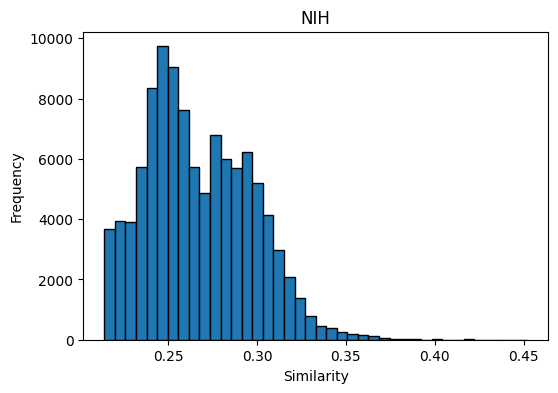

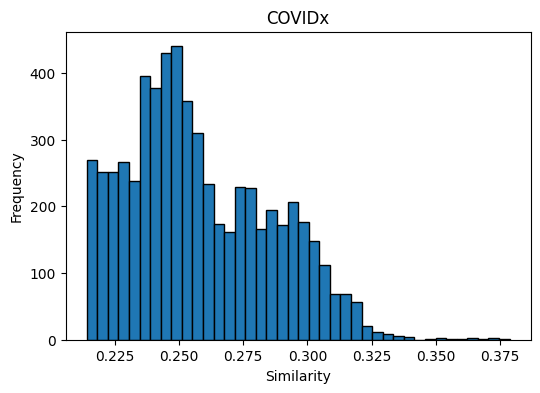

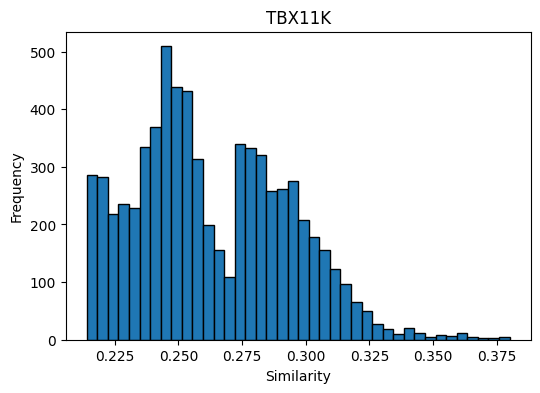

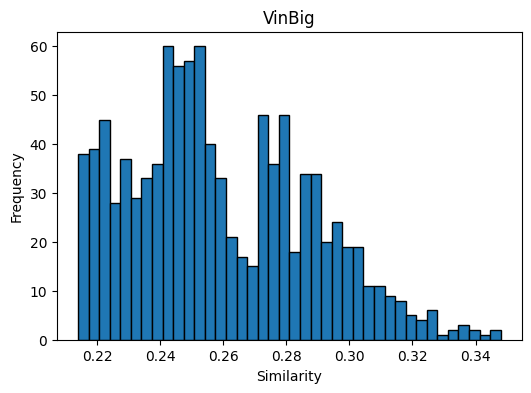

In [46]:
# ============================================================
# Cell 40 : Similarity Distribution
# ============================================================

def similarity_distribution(df,name):

    scores=[]

    for conf in df["confidence"]:

        scores.extend(conf)

    if len(scores)==0:

        return

    plt.figure(figsize=(6,4))

    plt.hist(

        scores,

        bins=40,

        edgecolor="black"

    )

    plt.title(name)

    plt.xlabel("Similarity")

    plt.ylabel("Frequency")

    plt.show()

similarity_distribution(results_df,"NIH")

similarity_distribution(covid_results,"COVIDx")

similarity_distribution(tb_results,"TBX11K")

similarity_distribution(vin_results,"VinBig")

In [47]:
# ============================================================
# Cell 41 : Final Summary
# ============================================================

summary = pd.DataFrame({

    "Dataset":[

        "NIH",

        "COVIDx",

        "TBX11K",

        "VinBig"

    ],

    "Images":[

        len(results_df),

        len(covid_results),

        len(tb_results),

        len(vin_results)

    ],

    "Avg Predictions":[

        results_df["predictions"].apply(len).mean(),

        covid_results["num_predictions"].mean(),

        tb_results["num_predictions"].mean(),

        vin_results["num_predictions"].mean()

    ],

    "Unknown Rate (%)":[

        (results_df["predictions"].apply(len)==0).mean()*100,

        (covid_results["num_predictions"]==0).mean()*100,

        (tb_results["num_predictions"]==0).mean()*100,

        (vin_results["num_predictions"]==0).mean()*100

    ]

})

display(summary)

,Dataset,Images,Avg Predictions,Unknown Rate (%)
0,NIH,112120,0.941536,62.209240
1,COVIDx,8482,0.712214,65.550578
2,TBX11K,12174,0.567028,76.909808
3,VinBig,3000,0.335000,84.733333


In [48]:
# ============================================================
# Cell 42 : Save Evaluation Results
# ============================================================

results_df.to_csv(

    "/kaggle/working/nih_results.csv",

    index=False

)

covid_results.to_csv(

    "/kaggle/working/covidx_results.csv",

    index=False

)

tb_results.to_csv(

    "/kaggle/working/tbx11k_results.csv",

    index=False

)

vin_results.to_csv(

    "/kaggle/working/vinbig_results.csv",

    index=False

)

summary.to_csv(

    "/kaggle/working/final_summary.csv",

    index=False

)

print("="*70)

print("Evaluation Results Saved Successfully")

print("/kaggle/working")

print("="*70)

Evaluation Results Saved Successfully
/kaggle/working


In [49]:
# ============================================================
# Cell 43 : Save Complete Experiment
# ============================================================

experiment = {

    "prototype_bank":prototype_bank,

    "summary":summary,

    "adaptive_thresholds":adaptive_thresholds,

    "diseases":DISEASES,

    "ema_alpha":EMA_ALPHA,

    "num_prototypes":NUM_PROTOTYPES

}

torch.save(

    experiment,

    "/kaggle/working/final_open_set_results.pth"

)

print("="*70)

print("Complete Experiment Saved")

print("="*70)

Complete Experiment Saved


In [50]:
# ============================================================
# Cell 44 : Final Experiment Report
# ============================================================

print("\n" + "=" * 90)
print("         TRUSTWORTHY OPEN-SET CHEST X-RAY DIAGNOSIS")
print("=" * 90)

print("\nModel")
print("-" * 90)
print("Backbone                : ConvNeXt-Tiny")
print("Embedding Dimension     :", EMBED_DIM)
print("Prototype Memory        : Multi-Prototype")
print("Prototypes per Class    :", NUM_PROTOTYPES)
print("Adaptive Thresholds     : Enabled")
print("EMA Prototype Update    : Enabled")
print("Embedding Normalization : L2")
print("Similarity Metric       : Cosine Similarity")

print("\nDatasets Evaluated")
print("-" * 90)
print(f"NIH ChestX-ray14        : {len(results_df):,} images")
print(f"COVIDx                 : {len(covid_results):,} images")
print(f"TBX11K                 : {len(tb_results):,} images")
print(f"VinBigData             : {len(vin_results):,} images")

print("\nPrediction Statistics")
print("-" * 90)

print(f"NIH Avg Predictions/Image      : {results_df['predictions'].apply(len).mean():.3f}")
print(f"COVIDx Avg Predictions/Image   : {covid_results['num_predictions'].mean():.3f}")
print(f"TBX11K Avg Predictions/Image   : {tb_results['num_predictions'].mean():.3f}")
print(f"VinBig Avg Predictions/Image   : {vin_results['num_predictions'].mean():.3f}")

print("\nUnknown Detection Rate")
print("-" * 90)

print(f"NIH                     : {(results_df['predictions'].apply(len)==0).mean()*100:.2f}%")
print(f"COVIDx                  : {(covid_results['num_predictions']==0).mean()*100:.2f}%")
print(f"TBX11K                  : {(tb_results['num_predictions']==0).mean()*100:.2f}%")
print(f"VinBig                  : {(vin_results['num_predictions']==0).mean()*100:.2f}%")

print("\nSaved Files")
print("-" * 90)

print("✓ nih_results.csv")
print("✓ covidx_results.csv")
print("✓ tbx11k_results.csv")
print("✓ vinbig_results.csv")
print("✓ final_summary.csv")
print("✓ final_open_set_results.pth")

print("\nOutput Directory")
print("-" * 90)
print("/kaggle/working/")

print("\n" + "=" * 90)
print("Evaluation Completed Successfully")
print("=" * 90)


         TRUSTWORTHY OPEN-SET CHEST X-RAY DIAGNOSIS

Model
------------------------------------------------------------------------------------------
Backbone                : ConvNeXt-Tiny
Embedding Dimension     : 768
Prototype Memory        : Multi-Prototype
Prototypes per Class    : 3
Adaptive Thresholds     : Enabled
EMA Prototype Update    : Enabled
Embedding Normalization : L2
Similarity Metric       : Cosine Similarity

Datasets Evaluated
------------------------------------------------------------------------------------------
NIH ChestX-ray14        : 112,120 images
COVIDx                 : 8,482 images
TBX11K                 : 12,174 images
VinBigData             : 3,000 images

Prediction Statistics
------------------------------------------------------------------------------------------
NIH Avg Predictions/Image      : 0.942
COVIDx Avg Predictions/Image   : 0.712
TBX11K Avg Predictions/Image   : 0.567
VinBig Avg Predictions/Image   : 0.335

Unknown Detection Rate
-------

In [51]:
# ============================================================
# Cell 45 : Unknown Detection Accuracy
# ============================================================

def unknown_accuracy(df):

    total = len(df)

    predicted_unknown = (df["num_predictions"] == 0).sum()

    accuracy = predicted_unknown / total

    return accuracy


covid_acc = unknown_accuracy(covid_results)

tb_acc = unknown_accuracy(tb_results)

vin_acc = unknown_accuracy(vin_results)

print("="*80)

print("UNKNOWN DETECTION ACCURACY")

print("="*80)

print(f"COVIDx    : {covid_acc:.4f} ({covid_acc*100:.2f}%)")

print(f"TBX11K    : {tb_acc:.4f} ({tb_acc*100:.2f}%)")

print(f"VinBig    : {vin_acc:.4f} ({vin_acc*100:.2f}%)")

print("="*80)

UNKNOWN DETECTION ACCURACY
COVIDx    : 0.6555 (65.55%)
TBX11K    : 0.7691 (76.91%)
VinBig    : 0.8473 (84.73%)


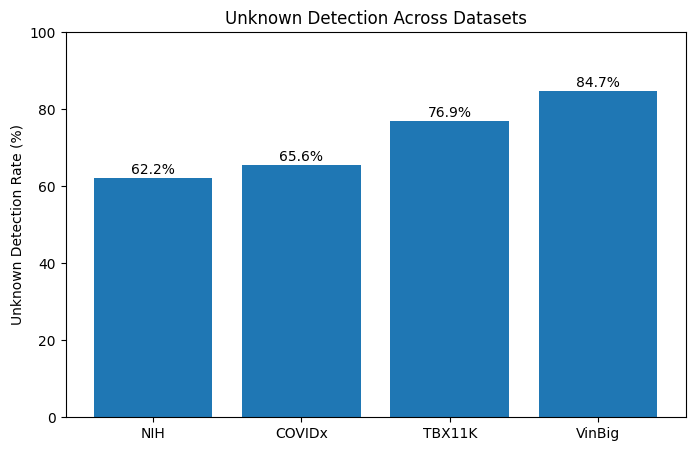

In [52]:
# ============================================================
# Cell 45 : Unknown Detection Rate
# ============================================================

datasets = [

    "NIH",

    "COVIDx",

    "TBX11K",

    "VinBig"

]

unknown_rate = [

    (results_df["predictions"].apply(len)==0).mean()*100,

    (covid_results["num_predictions"]==0).mean()*100,

    (tb_results["num_predictions"]==0).mean()*100,

    (vin_results["num_predictions"]==0).mean()*100

]

plt.figure(figsize=(8,5))

bars = plt.bar(

    datasets,

    unknown_rate

)

plt.ylabel("Unknown Detection Rate (%)")

plt.title("Unknown Detection Across Datasets")

plt.ylim(0,100)

for bar,value in zip(bars,unknown_rate):

    plt.text(

        bar.get_x()+bar.get_width()/2,

        value+1,

        f"{value:.1f}%",

        ha="center"

    )

plt.show()

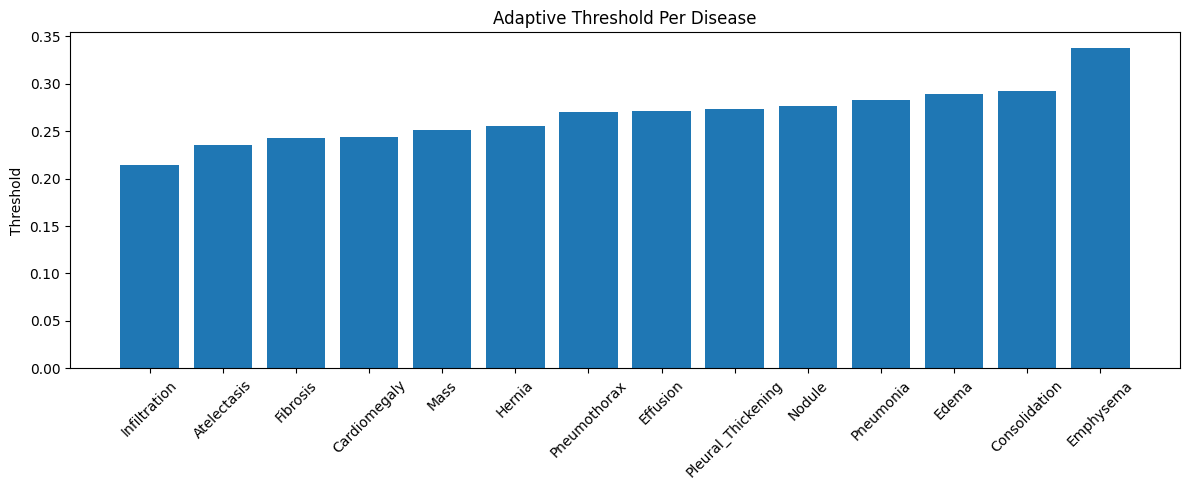

In [53]:
# ============================================================
# Cell 47 : Adaptive Thresholds
# ============================================================

threshold_df = pd.DataFrame({

    "Disease": list(adaptive_thresholds.keys()),

    "Threshold": list(adaptive_thresholds.values())

})

threshold_df = threshold_df.sort_values(

    "Threshold"

)

plt.figure(figsize=(12,5))

plt.bar(

    threshold_df["Disease"],

    threshold_df["Threshold"]

)

plt.xticks(rotation=45)

plt.ylabel("Threshold")

plt.title("Adaptive Threshold Per Disease")

plt.tight_layout()

plt.show()

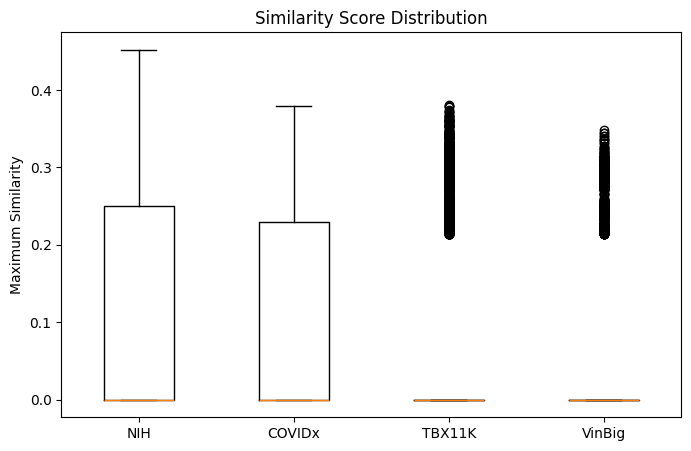

In [54]:
# ============================================================
# Cell 49 : Similarity Boxplot
# ============================================================

box_data = [

    [max(x) if len(x)>0 else 0 for x in results_df["confidence"]],

    [max(x) if len(x)>0 else 0 for x in covid_results["confidence"]],

    [max(x) if len(x)>0 else 0 for x in tb_results["confidence"]],

    [max(x) if len(x)>0 else 0 for x in vin_results["confidence"]]

]

plt.figure(figsize=(8,5))

plt.boxplot(

    box_data,

    labels=[

        "NIH",

        "COVIDx",

        "TBX11K",

        "VinBig"

    ]

)

plt.ylabel("Maximum Similarity")

plt.title("Similarity Score Distribution")

plt.show()

In [55]:
# ============================================================
# Cell 50 : Dataset Comparison
# ============================================================

comparison = pd.DataFrame({

    "Dataset":[

        "NIH",

        "COVIDx",

        "TBX11K",

        "VinBig"

    ],

    "Images":[

        len(results_df),

        len(covid_results),

        len(tb_results),

        len(vin_results)

    ],

    "Avg Predictions":[

        results_df["predictions"].apply(len).mean(),

        covid_results["num_predictions"].mean(),

        tb_results["num_predictions"].mean(),

        vin_results["num_predictions"].mean()

    ],

    "Unknown Rate":[

        (results_df["predictions"].apply(len)==0).mean()*100,

        (covid_results["num_predictions"]==0).mean()*100,

        (tb_results["num_predictions"]==0).mean()*100,

        (vin_results["num_predictions"]==0).mean()*100

    ]

})

display(comparison)

,Dataset,Images,Avg Predictions,Unknown Rate
0,NIH,112120,0.941536,62.209240
1,COVIDx,8482,0.712214,65.550578
2,TBX11K,12174,0.567028,76.909808
3,VinBig,3000,0.335000,84.733333


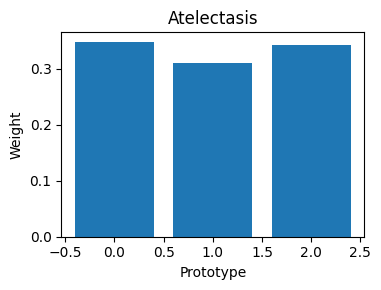

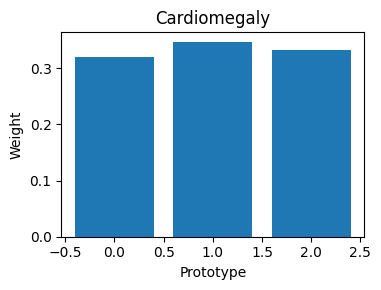

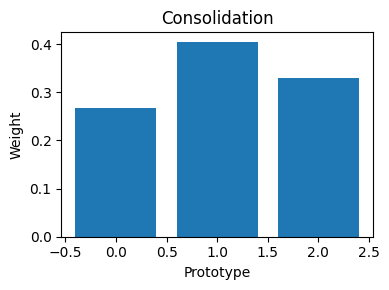

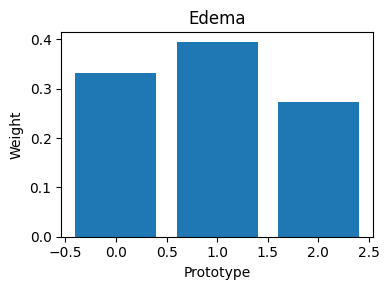

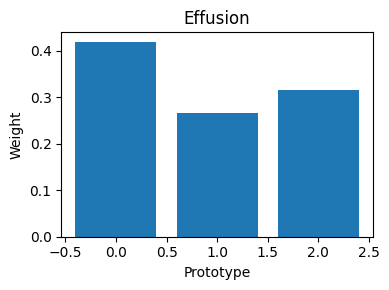

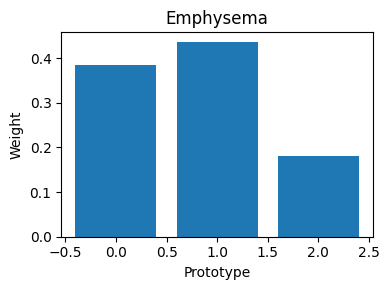

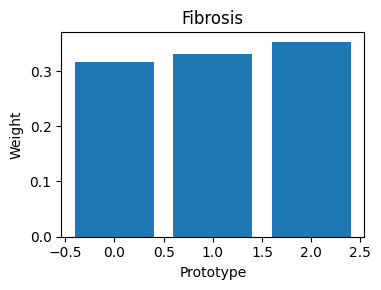

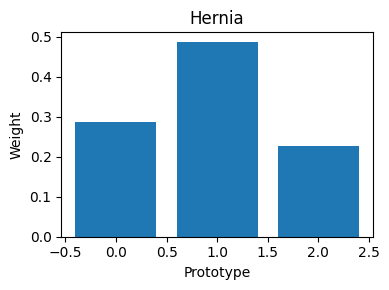

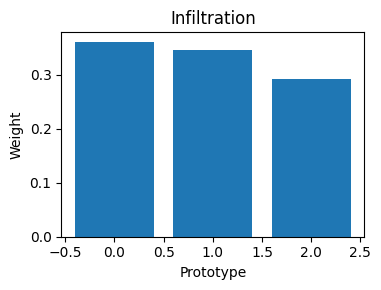

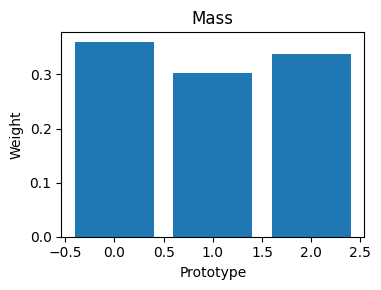

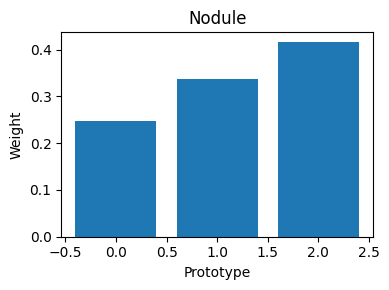

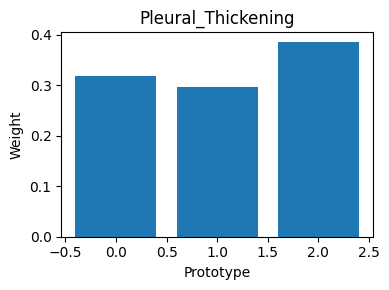

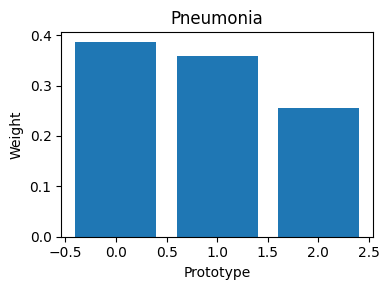

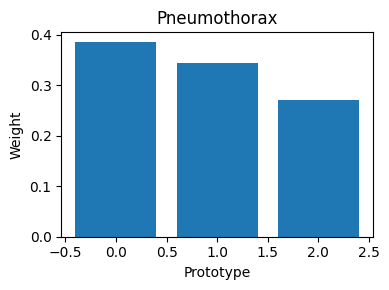

In [56]:
# ============================================================
# Cell 48 : Prototype Weight Distribution
# ============================================================

for disease in DISEASES:

    weights = prototype_weights[disease]

    # Convert to NumPy if it's a torch tensor
    if torch.is_tensor(weights):

        weights = weights.detach().cpu().numpy()

    plt.figure(figsize=(4,3))

    plt.bar(

        range(len(weights)),

        weights

    )

    plt.title(disease)

    plt.xlabel("Prototype")

    plt.ylabel("Weight")

    plt.tight_layout()

    plt.show()

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


Embedding Matrix : (2048, 768)


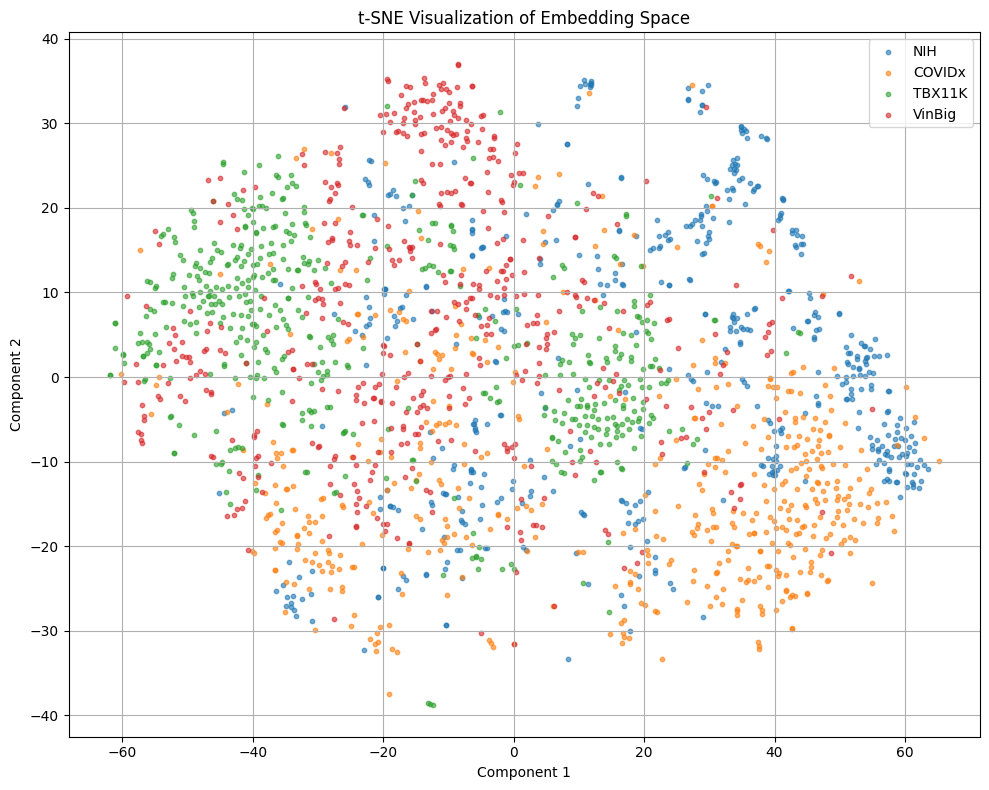

In [57]:
# ============================================================
# Cell 51 : t-SNE Visualization
# ============================================================

from sklearn.manifold import TSNE

NUM_SAMPLES = 500

embeddings = []
labels = []

encoder.eval()

# -----------------------------
# NIH
# -----------------------------
count = 0

with torch.no_grad():

    for images, _, _ in nih_loader:

        images = images.to(DEVICE)

        emb = extract_embedding(images)

        embeddings.append(

            emb.cpu().numpy()

        )

        labels.extend(

            ["NIH"] * len(images)

        )

        count += len(images)

        if count >= NUM_SAMPLES:

            break

# -----------------------------
# COVIDx
# -----------------------------
count = 0

with torch.no_grad():

    for images, _ in covid_loader:

        images = images.to(DEVICE)

        emb = extract_embedding(images)

        embeddings.append(

            emb.cpu().numpy()

        )

        labels.extend(

            ["COVIDx"] * len(images)

        )

        count += len(images)

        if count >= NUM_SAMPLES:

            break

# -----------------------------
# TBX11K
# -----------------------------
count = 0

with torch.no_grad():

    for images, _ in tb_loader:

        images = images.to(DEVICE)

        emb = extract_embedding(images)

        embeddings.append(

            emb.cpu().numpy()

        )

        labels.extend(

            ["TBX11K"] * len(images)

        )

        count += len(images)

        if count >= NUM_SAMPLES:

            break

# -----------------------------
# VinBig
# -----------------------------
count = 0

with torch.no_grad():

    for images, _ in vin_loader:

        images = images.to(DEVICE)

        emb = extract_embedding(images)

        embeddings.append(

            emb.cpu().numpy()

        )

        labels.extend(

            ["VinBig"] * len(images)

        )

        count += len(images)

        if count >= NUM_SAMPLES:

            break

embeddings = np.concatenate(

    embeddings,

    axis=0

)

print("="*70)

print("Embedding Matrix :", embeddings.shape)

print("="*70)

tsne = TSNE(

    n_components=2,

    perplexity=30,

    random_state=42,

    init="pca"

)

reduced = tsne.fit_transform(

    embeddings

)

plt.figure(figsize=(10,8))

colors = {

    "NIH":"blue",

    "COVIDx":"red",

    "TBX11K":"green",

    "VinBig":"orange"

}

for dataset in colors:

    idx = np.array(labels)==dataset

    plt.scatter(

        reduced[idx,0],

        reduced[idx,1],

        s=10,

        alpha=0.6,

        label=dataset

    )

plt.legend()

plt.title("t-SNE Visualization of Embedding Space")

plt.xlabel("Component 1")

plt.ylabel("Component 2")

plt.grid(True)

plt.tight_layout()

plt.show()

Prototype Shape : (42, 768)


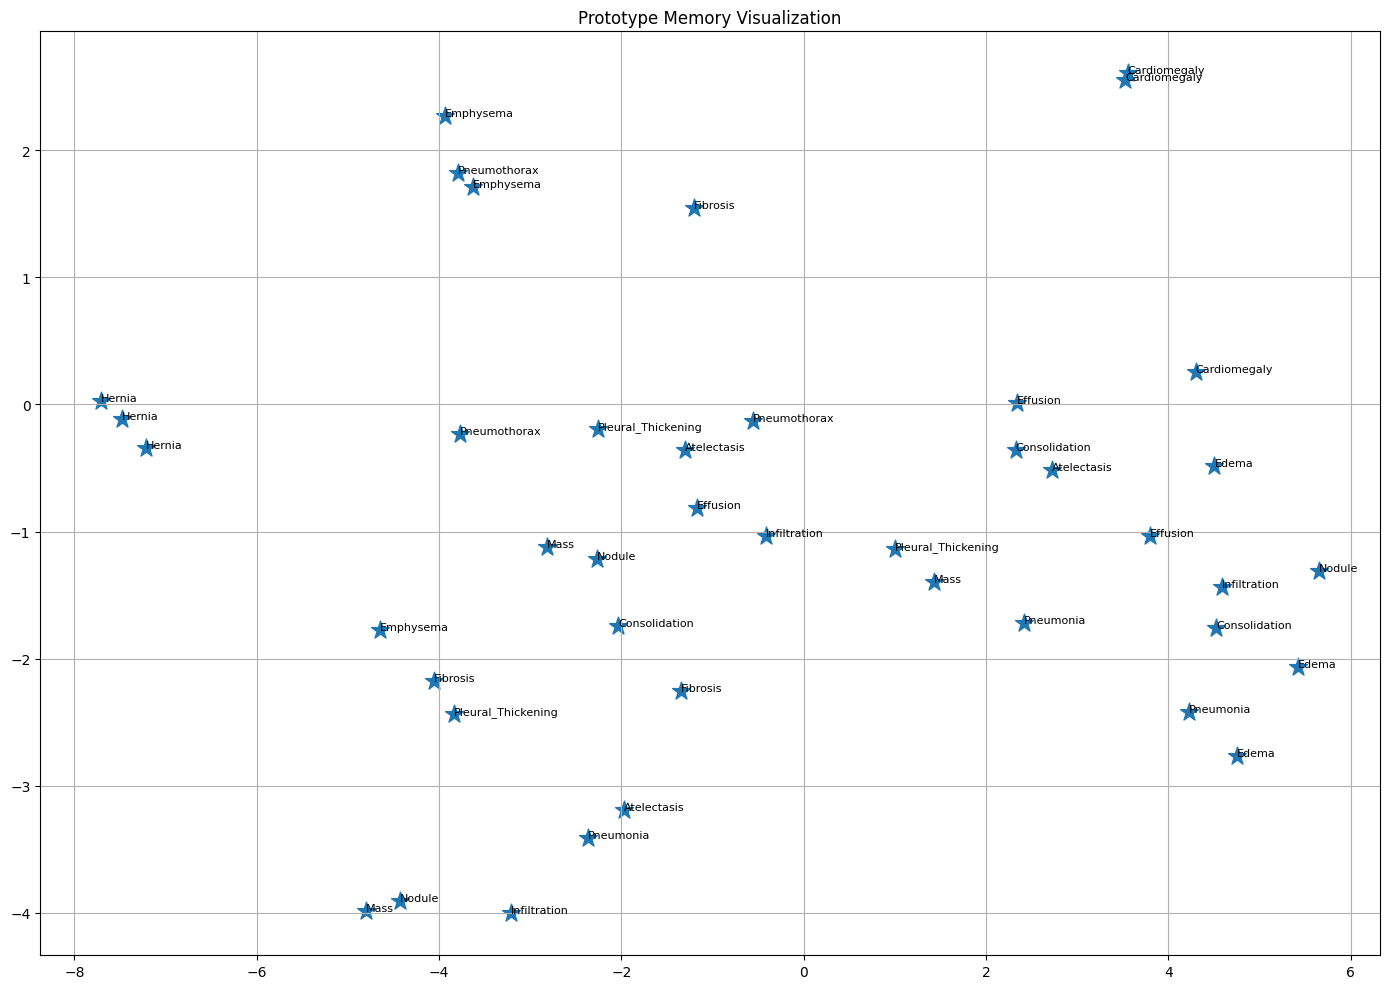

In [58]:
# ============================================================
# Cell 52 : Prototype Memory t-SNE
# ============================================================

from sklearn.manifold import TSNE

prototype_embeddings = []
prototype_labels = []

for disease in DISEASES:

    protos = prototype_memory[disease]

    if torch.is_tensor(protos):

        protos = protos.detach().cpu().numpy()

    for p in protos:

        prototype_embeddings.append(p)

        prototype_labels.append(disease)

prototype_embeddings = np.array(prototype_embeddings)

print("="*70)

print("Prototype Shape :", prototype_embeddings.shape)

print("="*70)

tsne = TSNE(

    n_components=2,

    random_state=42,

    perplexity=15,

    init="pca"

)

prototype_tsne = tsne.fit_transform(

    prototype_embeddings

)

plt.figure(figsize=(14,10))

plt.scatter(

    prototype_tsne[:,0],

    prototype_tsne[:,1],

    s=180,

    marker="*"

)

for i,disease in enumerate(prototype_labels):

    plt.text(

        prototype_tsne[i,0],

        prototype_tsne[i,1],

        disease,

        fontsize=8

    )

plt.title("Prototype Memory Visualization")

plt.grid(True)

plt.tight_layout()

plt.show()

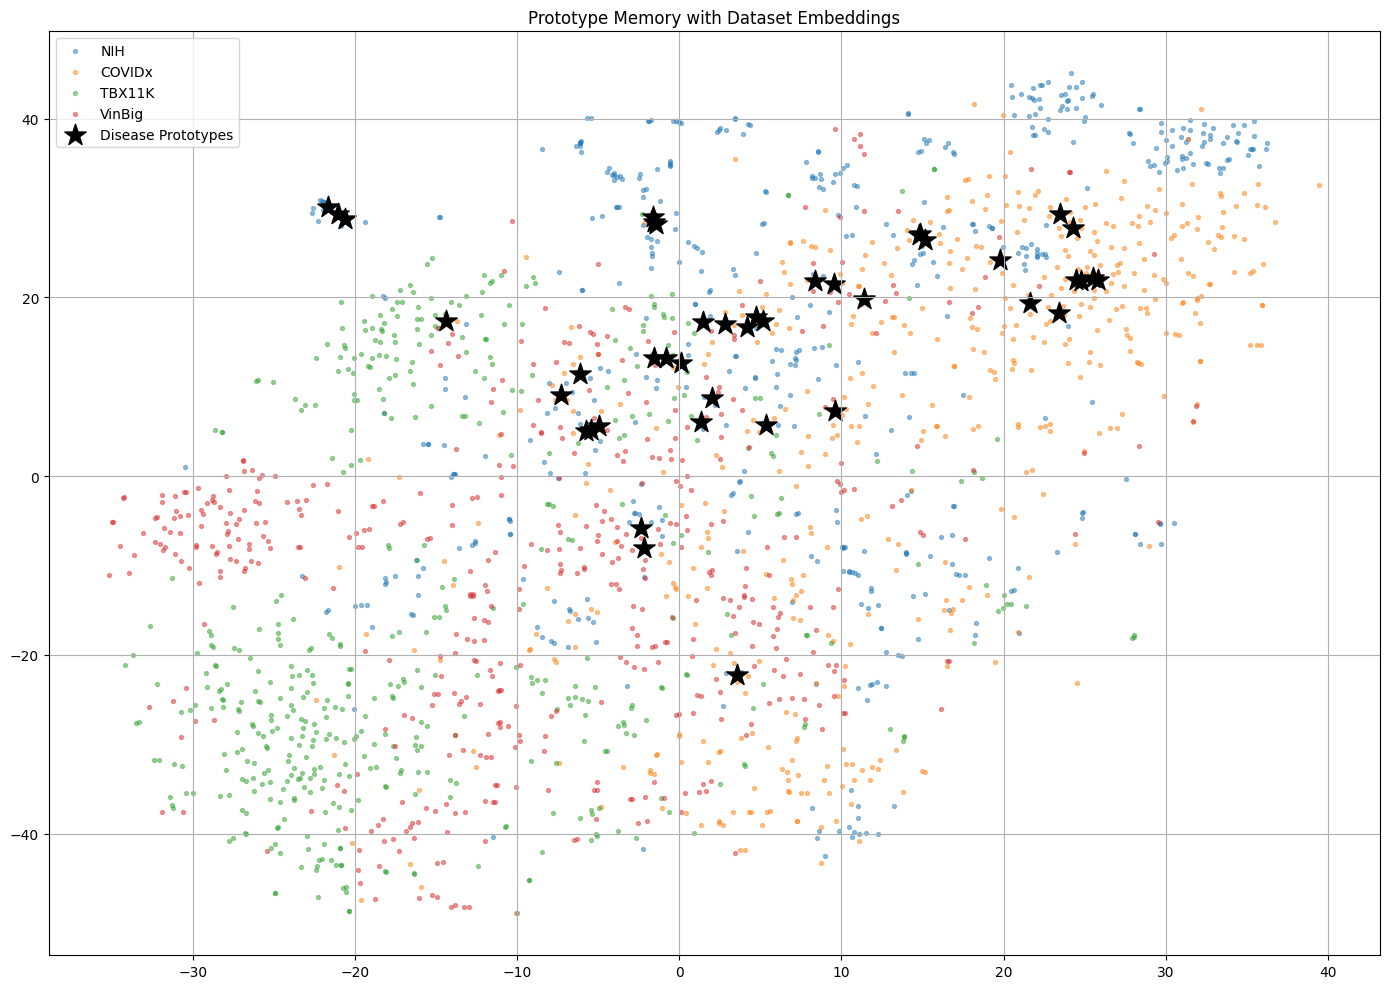

In [59]:
# ============================================================
# Cell 53 : Prototype + Dataset Embeddings
# ============================================================

combined_embeddings = np.concatenate(

    [

        embeddings,

        prototype_embeddings

    ],

    axis=0

)

combined_labels = labels + prototype_labels

combined_tsne = TSNE(

    n_components=2,

    random_state=42,

    perplexity=30,

    init="pca"

).fit_transform(

    combined_embeddings

)

plt.figure(figsize=(14,10))

# ----------------------------
# Dataset embeddings
# ----------------------------

dataset_colors = {

    "NIH":"blue",

    "COVIDx":"red",

    "TBX11K":"green",

    "VinBig":"orange"

}

for dataset,color in dataset_colors.items():

    idx = np.array(combined_labels)==dataset

    plt.scatter(

        combined_tsne[idx,0],

        combined_tsne[idx,1],

        s=8,

        alpha=0.45,

        label=dataset

    )

# ----------------------------
# Prototype stars
# ----------------------------

proto_start = len(embeddings)

plt.scatter(

    combined_tsne[proto_start:,0],

    combined_tsne[proto_start:,1],

    s=260,

    marker="*",

    color="black",

    label="Disease Prototypes"

)

plt.legend()

plt.title(

    "Prototype Memory with Dataset Embeddings"

)

plt.grid(True)

plt.tight_layout()

plt.show()

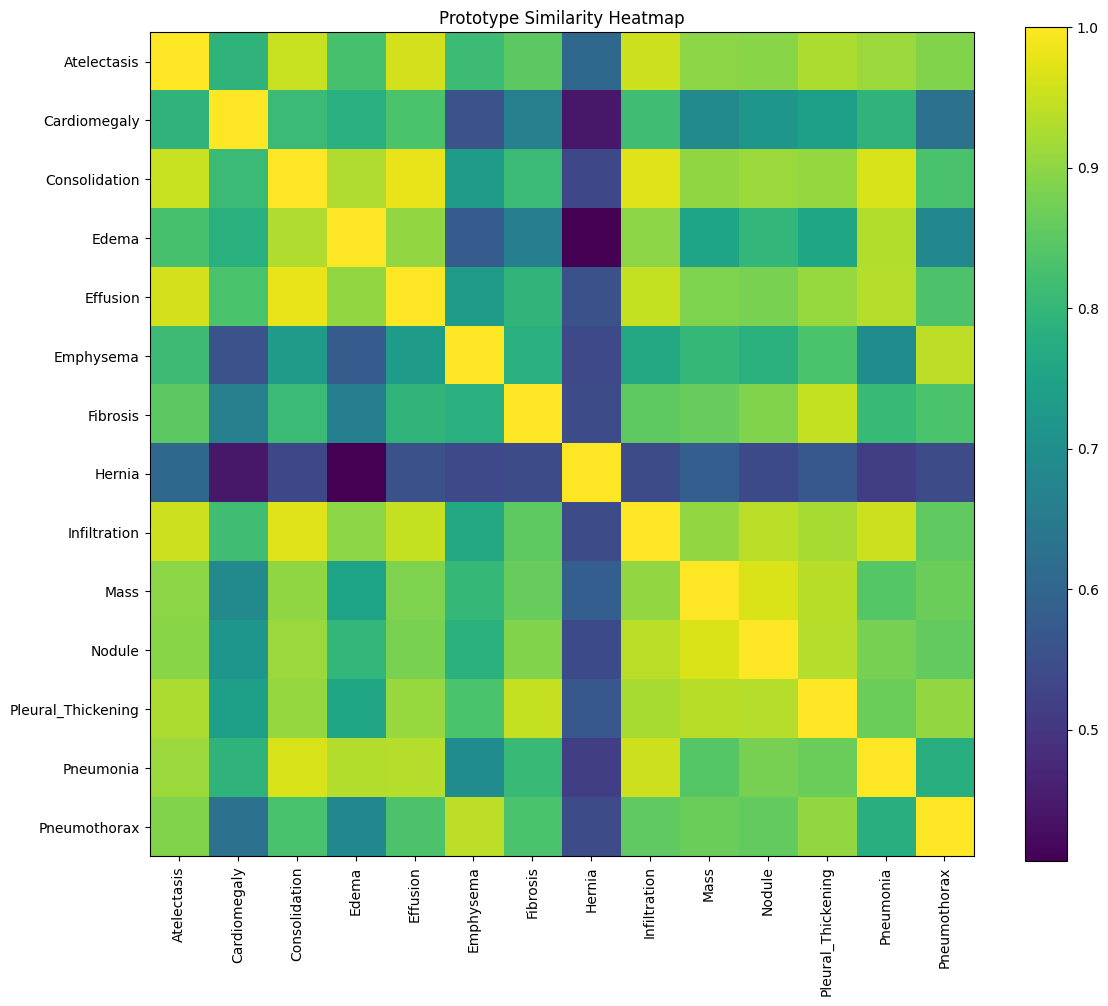

In [60]:
# ============================================================
# Cell 54 : Prototype Similarity Heatmap
# ============================================================

prototype_matrix = []

for disease in DISEASES:

    proto = prototype_memory[disease]

    if torch.is_tensor(proto):

        proto = proto.mean(0).detach().cpu().numpy()

    prototype_matrix.append(proto)

prototype_matrix = np.array(prototype_matrix)

prototype_matrix = prototype_matrix / np.linalg.norm(

    prototype_matrix,

    axis=1,

    keepdims=True

)

similarity = prototype_matrix @ prototype_matrix.T

plt.figure(figsize=(12,10))

plt.imshow(

    similarity,

    cmap="viridis"

)

plt.colorbar()

plt.xticks(

    range(len(DISEASES)),

    DISEASES,

    rotation=90

)

plt.yticks(

    range(len(DISEASES)),

    DISEASES

)

plt.title("Prototype Similarity Heatmap")

plt.tight_layout()

plt.show()

In [61]:
# ============================================================
# Cell XX : Known Disease Classification Metrics
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    hamming_loss,
    precision_score,
    recall_score,
    f1_score
)

# Ground truth
y_true = np.stack(nih_df["target"].values)

# Predictions
y_pred = np.zeros_like(y_true)

for i, preds in enumerate(results_df["predictions"]):

    for disease in preds:

        if disease in DISEASES:

            idx = DISEASES.index(disease)

            y_pred[i, idx] = 1

exact_acc = accuracy_score(y_true, y_pred)

hamming_acc = 1 - hamming_loss(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

print("="*80)

print("KNOWN DISEASE PERFORMANCE")

print("="*80)

print(f"Exact Match Accuracy : {exact_acc:.4f}")

print(f"Hamming Accuracy     : {hamming_acc:.4f}")

print(f"Precision            : {precision:.4f}")

print(f"Recall               : {recall:.4f}")

print(f"F1 Score             : {f1:.4f}")

print("="*80)

KNOWN DISEASE PERFORMANCE
Exact Match Accuracy : 0.4629
Hamming Accuracy     : 0.9181
Precision            : 0.2661
Recall               : 0.2776
F1 Score             : 0.2526


In [62]:
# ============================================================
# Final Evaluation Metrics
# ============================================================

import numpy as np

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    jaccard_score,

    hamming_loss

)

# --------------------------------------------------------
# Ground Truth
# --------------------------------------------------------

y_true = np.stack(

    nih_df["target"].values

)

# --------------------------------------------------------
# Predictions
# --------------------------------------------------------

y_pred = np.zeros_like(y_true)

for i, preds in enumerate(results_df["predictions"]):

    for disease in preds:

        if disease in DISEASES:

            idx = DISEASES.index(disease)

            y_pred[i, idx] = 1

# --------------------------------------------------------
# Known Metrics
# --------------------------------------------------------

subset_accuracy = accuracy_score(

    y_true,

    y_pred

)

exact_match_accuracy = subset_accuracy

hamming = hamming_loss(

    y_true,

    y_pred

)

hamming_accuracy = 1 - hamming

precision_macro = precision_score(

    y_true,

    y_pred,

    average="macro",

    zero_division=0

)

recall_macro = recall_score(

    y_true,

    y_pred,

    average="macro",

    zero_division=0

)

f1_macro = f1_score(

    y_true,

    y_pred,

    average="macro",

    zero_division=0

)

precision_micro = precision_score(

    y_true,

    y_pred,

    average="micro",

    zero_division=0

)

recall_micro = recall_score(

    y_true,

    y_pred,

    average="micro",

    zero_division=0

)

f1_micro = f1_score(

    y_true,

    y_pred,

    average="micro",

    zero_division=0

)

jaccard = jaccard_score(

    y_true,

    y_pred,

    average="samples",

    zero_division=0

)

known_acceptance = (

    results_df["predictions"]

    .apply(len)

    .gt(0)

    .mean()

)

# --------------------------------------------------------
# Unknown Metrics
# --------------------------------------------------------

covid_unknown = (

    covid_results["num_predictions"]

    .eq(0)

    .mean()

)

tb_unknown = (

    tb_results["num_predictions"]

    .eq(0)

    .mean()

)

vin_unknown = (

    vin_results["num_predictions"]

    .eq(0)

    .mean()

)

avg_unknown = np.mean(

    [

        covid_unknown,

        tb_unknown,

        vin_unknown

    ]

)

# --------------------------------------------------------
# Open Set Score
# --------------------------------------------------------

open_set_score = (

    known_acceptance +

    f1_macro +

    avg_unknown

) / 3

# --------------------------------------------------------
# Print
# --------------------------------------------------------

print("\n"+"="*90)

print("FINAL PERFORMANCE REPORT")

print("="*90)

print("\nKNOWN DATASET (NIH)")

print("-"*90)

print(f"Subset Accuracy          : {subset_accuracy:.4f}")

print(f"Exact Match Accuracy     : {exact_match_accuracy:.4f}")

print(f"Hamming Accuracy         : {hamming_accuracy:.4f}")

print(f"Hamming Loss             : {hamming:.4f}")

print(f"Macro Precision          : {precision_macro:.4f}")

print(f"Macro Recall             : {recall_macro:.4f}")

print(f"Macro F1                 : {f1_macro:.4f}")

print(f"Micro Precision          : {precision_micro:.4f}")

print(f"Micro Recall             : {recall_micro:.4f}")

print(f"Micro F1                 : {f1_micro:.4f}")

print(f"Jaccard Score            : {jaccard:.4f}")

print(f"Known Acceptance Rate    : {known_acceptance:.4f}")

print("\nUNKNOWN DATASETS")

print("-"*90)

print(f"COVIDx Accuracy          : {covid_unknown:.4f}")

print(f"TBX11K Accuracy          : {tb_unknown:.4f}")

print(f"VinBig Accuracy          : {vin_unknown:.4f}")

print(f"Average Unknown Accuracy : {avg_unknown:.4f}")

print("\nOVERALL")

print("-"*90)

print(f"Open Set Score           : {open_set_score:.4f}")

print("="*90)


FINAL PERFORMANCE REPORT

KNOWN DATASET (NIH)
------------------------------------------------------------------------------------------
Subset Accuracy          : 0.4629
Exact Match Accuracy     : 0.4629
Hamming Accuracy         : 0.9181
Hamming Loss             : 0.0819
Macro Precision          : 0.2661
Macro Recall             : 0.2776
Macro F1                 : 0.2526
Micro Precision          : 0.2754
Micro Recall             : 0.3581
Micro F1                 : 0.3113
Jaccard Score            : 0.0908
Known Acceptance Rate    : 0.3779

UNKNOWN DATASETS
------------------------------------------------------------------------------------------
COVIDx Accuracy          : 0.6555
TBX11K Accuracy          : 0.7691
VinBig Accuracy          : 0.8473
Average Unknown Accuracy : 0.7573

OVERALL
------------------------------------------------------------------------------------------
Open Set Score           : 0.4626
